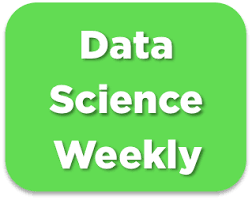

# EDA

## Import libraries

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, confusion_matrix

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
# setting Jedha color palette as default
pio.templates["jedha"] = go.layout.Template(
    layout_colorway=["#4B9AC7", "#4BE8E0", "#9DD4F3", "#97FBF6", "#2A7FAF", "#23B1AB", "#0E3449", "#015955"]
)
pio.templates.default = "jedha"
#pio.renderers.default = "svg" # to be replaced by "iframe" if working on JULIE
from IPython.display import display

# Read file with labels

In [32]:
df = pd.read_csv('conversion_data_train.csv')
print('Set with labels (our train+test) :', df.shape)

Set with labels (our train+test) : (284580, 6)


In [3]:
df.head()

,country,age,new_user,source,total_pages_visited,converted
0,China,22,1,Direct,2,0
1,UK,21,1,Ads,3,0
2,Germany,20,0,Seo,14,1
3,US,23,1,Seo,3,0
4,US,28,1,Direct,3,0


In [ ]:
df['converted'] = df['converted'].astype(str)


In [17]:
nb_convertis = (df['converted'] == "1").sum()
nb_non_convertis = (df['converted'] == "0").sum()
ratio_convertis = (nb_convertis / df.shape[0]) * 100
ratio_non_convertis = (nb_non_convertis / df.shape[0]) * 100

In [18]:
ratio_convertis = (nb_convertis / df.shape[0]) * 100
ratio_non_convertis = (nb_non_convertis / df.shape[0]) * 100

## Ratio Convertis VS Non Convertis

In [42]:
import pandas as pd
import plotly.graph_objects as go

# Création d'un DataFrame avec les ratios
data = {
    'Statut': ['Convertis', 'Non Convertis'],
    'Ratio': [nb_convertis, nb_non_convertis]
}
df_ratios = pd.DataFrame(data)

# Déterminer l'index de la plus petite section
smallest_index = df_ratios['Ratio'].idxmin()

# Définir les couleurs
colors = ['#388730ff' if i == df_ratios['Ratio'].idxmax() else '#ffe49e' for i in range(len(df_ratios))]

# Création du camembert avec Plotly graph_objects
fig = go.Figure(data=[go.Pie(
    labels=df_ratios['Statut'],
    values=df_ratios['Ratio'],
    pull=[0.1 if i == smallest_index else 0 for i in range(len(df_ratios))],
    marker=dict(colors=colors),
    textinfo='label+percent',
    textfont=dict(size=20, color='black', family="Arial, bold")
)])

# Mise à jour du titre
fig.update_layout(title_text='Ratio des Convertis et Non Convertis')

# Affichage du graphique
fig.show()


# EDA Explore dataset

In [33]:
from skimpy import skim
skim(df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 284580 │ │ int64       │ 4     │                                                          │
│ │ Number of columns │ 6      │ │ string      │ 2     │                                                          │
│ └───────────────────┴────────┘ └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━━┓  │
│ ┃ column                   ┃ NA  ┃ NA %   ┃ mean      ┃ sd       ┃ p0  ┃ p25  ┃ p50  ┃ p75  ┃ p100  ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━━┩  │
│ │ age                      │   0 │      0 │     30.56 │    8.267 │  17 │   24 │   30 │   36 │   123 │   █▃   │  │
│ │ new_user                 │   0 │      0 │    0.6855 │   0.4643 │   0 │    0 │    1 │    1 │     1 │ ▄    █ │  │
│ │ total_pages_visited      │   0 │      0 │     4.873 │    3.342 │   1 │    2 │    4 │    7 │    29 │  █▄▁   │  │
│ │ converted                │   0 │      0 │   0.03226 │   0.1767 │   0 │    0 │    0 │    0 │     1 │   █    │  │
│ └──────────────────────────┴─────┴────────┴───────────┴──────────┴─────┴──────┴──────┴──────┴───────┴────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┳━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓  │
│ ┃ column   ┃ NA  ┃ NA %  ┃ shortest  ┃ longest  ┃ min    ┃ max ┃ chars per row ┃ words per row ┃ total words ┃  │
│ ┡━━━━━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━╇━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩  │
│ │ country  │   0 │     0 │ UK        │ Germany  │ China  │ US  │          2.93 │             1 │      284580 │  │
│ │ source   │   0 │     0 │ Ads       │ Direct   │ Ads    │ Seo │          3.69 │             1 │      284580 │  │
│ └──────────┴─────┴───────┴───────────┴──────────┴────────┴─────┴───────────────┴───────────────┴─────────────┘  │
╰────────────────────────────────────────────────────── End ──────────────────────────────────────────────────────╯

In [34]:
from summarytools import dfSummary
dfSummary(df)

No,Variable,Stats / Values,Freqs / (% of Valid),Graph,Missing
1,country[object],1. US2. China3. UK4. Germany,"160,124 (56.3%)69,122 (24.3%)43,641 (15.3%)11,693 (4.1%)","<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAJsAAABcCAYAAAB5jMeAAAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjAsIGh0dHBzOi8vbWF0cGxvdGxpYi5vcmcvlHJYcgAAAAlwSFlzAAAPYQAAD2EBqD+naQAAAfFJREFUeJzt20Fq21AYhdFfxYRmImEMXowX0cV2EdqNMdagCZmogxAwNMlIunqo56zgYT5kntDt5nkuSPix9QH4f4iNmK6qnqvqaeuD7NTbPM8vWx+iFYfT6fSr7/vj1gfZo2mabl3X/Rbcu0Pf98fL5fIyDMPr1ofZk/v9/nMcx+P1en2qKrFV1aGqahiG1/P5/Gfrw+zQ89YHaIkLAjFiI0ZsxIiNGLERIzZixEaM2IgRGzFiI0ZsxIiNGLERc6h6/xxm64Psjd/0X4dpmm7jOB7L5zCLm6bpVlVvW5+jFT4LX5fPwh90pnykuCAQ0/LfqL+gnWl2XWWZtD9Nrqssk/ap5XWVVzE744JAjNiIERsxYiNGbMSIjRixESM2YsRGjNiIERsxYiNGbMSIjZgmp3ytnYdlNDvlM4PbHxsEYkz5iEk82TyhqKrAuspKig+rrquspHiUWFc1dctlO17qEiM2YsRGjNiIERsxYiNGbMSIjRixESM2YsRGjNiIERsxYiNm1XWVlRSPVl9XWUnxwQaBGOsqYr57snkisagv11VWUSzt03WVVRRr+G5dZRXForzUJUZsxIiNGLERIzZixEaM2IgRGzFiI0ZsxIiNGLERIzZixEbMp+sqqyjW8OW6yiqKpdkgEGNdRYwLAjF/AbNY2LmAHpcBAAAAAElFTkSuQmCC"">",0(0.0%)
2,age[int64],Mean (sd) : 30.6 (8.3)min < med < max:17.0 < 30.0 < 123.0IQR (CV) : 12.0 (3.7),60 distinct values,"<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAKoAAABGCAYAAABc8A97AAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjAsIGh0dHBzOi8vbWF0cGxvdGxpYi5vcmcvlHJYcgAAAAlwSFlzAAAPYQAAD2EBqD+naQAAAjFJREFUeJzt3UGOokAYhuG/BjWoCcSY6M4LTNILlx5iDjtH6IUn8AbuTAzBSDcjIr3q1WS6hZJuPuZ99oUs3gB/YqVcVVUGdN2P774B4B6DNi/unBub2cjjEpeqql4fdT/Q1VqozrnxfD7/FUXRrOk1TqdT4pz7Taxo84k6iqJottlsXuM4zusuTtM03G63s+PxODIzQv3PtfrqNzOL4zhfLBYvDZePH3ozkMUwBQmECgmfvvo9JvfodrsNG6wD/vJhqD6Te1EUYVmWP/M8fzazpt+ogJl9/kRtPLnv9/vZbrebXK/XwOP+ADO7c+pvMrknScLEjodhmIIEQoUEQoUEQoUEQoUEQoUEQoUEQoUEQoUEQoUEQoUEQoUEQoUEQoUEQoUEQoUEQoUEQoUEQoUEQoUEQoUEQoUEQoUEQoUEQoUEQoUEQoUEQoUEQoUEQoUEQoUEQoUEQoUEQoWE1g9E81GW5dDMIudck+Wco9ojnQ01y7JhURRPq9UqCIKg9hGVnKPaL50N9XK5DMIwnKzX63y5XCZ11nKOav90NtR30+m06VmqnMrSIwxTkECokECokECokECokECokECokECokECokECokECokECokECokECokECokND5/6M25bmNxYytLJ3Sy1B9t7GYsZWla3oZqs82FjO2snRRL0N957GNxYytLJ1yV6hpmoZ1L3w+n0MzsyzLwsPhMPnK9b6/naZpWJblwPy+cVHPn6qq/vmZ9gYhuLjYOnlgCQAAAABJRU5ErkJggg=="">",0(0.0%)
3,new_user[int64],1. 12. 0,"195,066 (68.5%)89,514 (31.5%)","<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAJsAAAAuCAYAAAA/ZmtKAAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjAsIGh0dHBzOi8vbWF0cGxvdGxpYi5vcmcvlHJYcgAAAAlwSFlzAAAPYQAAD2EBqD+naQAAAT1JREFUeJzt20FqwzAURdGvYkIzkTAGLyaL6GK7CO3GGGvQhEzUQadtOjA8oa97VvAhN4EYv1BrNUAhmNnVzC6tD8G/nrXWe+sjzpiWZfmIMc6tD8FrpZQ9hPDZc3BTjHG+3W73lNKj9TH43XEc7znnedu2i5n1G5uZWUrpsa7rV+tj8NK19QFnvbU+AOMgNsgQG2SIDTLEBhligwyxQYbYIENskCE2yBAbZIgNMsQGGWKDDLFBZjL7eTmv9SH4m5fPZyql7Dnn2Ry8nOdZKWU3s2frO85g8NKP7gcvgSkfVLz8snX/rR+Biymfh5nbCLqf8nmZuY3Ay5SPf9Id4KEuZIgNMsQGGWKDDLFBhtggQ2yQITbIEBtkiA0yxAYZYoMMsUGG2CBDbJDpfsrX8+2jcTHl8zBzGwGDF8h8Awpbat9GRbT/AAAAAElFTkSuQmCC"">",0(0.0%)
4,source[object],1. Seo2. Ads3. Direct,"139,477 (49.0%)80,027 (28.1%)65,076 (22.9%)","<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAJsAAABFCAYAAABdVZTTAAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjAsIGh0dHBzOi8vbWF0cGxvdGxpYi5vcmcvlHJYcgAAAAlwSFlzAAAPYQAAD2EBqD+naQAAAZhJREFUeJzt20Fq2wAURdGvYkIzkTAGL8aL6GK7CO3GGGvQhEzUQacd1Cl90nfPWcHHXGwk/IZ1XQsSvmx9AP+Poapeq+pl60Ma+VjX9W3rIzo6nE6nb+M4Hrc+pItlWW7DMHwX3OMO4zgeL5fL2zRN71sfs3f3+/3rPM/H6/X6UlVie9Chqmqapvfz+fxj62OaeN36gK48IBAjNmLERozYiBEbMWIjRmzEiI0YsREjNmLERozYiBEbMWIj5lD1639aWx/Sgc/p7xyWZbnN83ws/9P6I8uy3KrqY+s7OrJBeJwNwicNpnykdPxm883SVLt1lXVTX63WVdZNvXVcV3lqbspLXWLERozYiBEbMWIjRmzEiI0YsREjNmLERozYiBEbMWIjRmzEtFpXdbmT32u3rrJu6ssGgRjrKmI8IBCzt59RP5FPbFdTPjO957abKZ+Z3vPb25SvxesXPscDAjFiI0ZsxIiNGLERIzZixEaM2IgRGzFiI0ZsxIiNGLERIzZidjPl28MN/Fu7mvKZ6T03GwRiTPmI+QlKvKNK4kuAvAAAAABJRU5ErkJggg=="">",0(0.0%)
5,total_pages_visited[int64],Mean (sd) : 4.9 (3.3)min < med < max:1.0 < 4.0 < 29.0IQR (CV) : 5.0 (1.5),29 distinct values,"<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAKoAAABGCAYAAABc8A97AA

In [17]:
# The dataset is quite big : you must create a sample of the dataset before making any visualizations !
data_sample = df.sample(10000)

In [18]:
data_sample.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 114347 to 61438
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   country              10000 non-null  object
 1   age                  10000 non-null  int64 
 2   new_user             10000 non-null  int64 
 3   source               10000 non-null  object
 4   total_pages_visited  10000 non-null  int64 
 5   converted            10000 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 546.9+ KB


In [19]:
data_sample.describe(include='all')

,country,age,new_user,source,total_pages_visited,converted
count,10000,10000.000000,10000.00000,10000,10000.000000,10000.000000
unique,4,NaN,NaN,3,NaN,NaN
top,US,NaN,NaN,Seo,NaN,NaN
freq,5630,NaN,NaN,4908,NaN,NaN
mean,NaN,30.654200,0.68550,NaN,4.860000,0.030500
std,NaN,8.258574,0.46434,NaN,3.313834,0.171967
min,NaN,17.000000,0.00000,NaN,1.000000,0.000000
25%,NaN,24.000000,0.00000,NaN,2.000000,0.000000
50%,NaN,30.000000,1.00000,NaN,4.000000,0.000000
75%,NaN,36.000000,1.00000,NaN,7.000000,0.000000


In [53]:
import pandas as pd
import plotly.express as px

# Calcul des moyennes pour la Chine et globalement
average_pages_visited_china_converted_0 = data_sample[(data_sample['country'] == 'China') & (data_sample['converted'] == 0)]['total_pages_visited'].mean()
average_pages_visited_china_converted_1 = data_sample[(data_sample['country'] == 'China') & (data_sample['converted'] == 1)]['total_pages_visited'].mean()
average_age_china_converted_0 = data_sample[(data_sample['country'] == 'China') & (data_sample['converted'] == 0)]['age'].mean()
average_age_china_converted_1 = data_sample[(data_sample['country'] == 'China') & (data_sample['converted'] == 1)]['age'].mean()

average_pages_visited_global_converted_0 = data_sample[data_sample['converted'] == 0]['total_pages_visited'].mean()
average_pages_visited_global_converted_1 = data_sample[data_sample['converted'] == 1]['total_pages_visited'].mean()
average_age_global_converted_0 = data_sample[data_sample['converted'] == 0]['age'].mean()
average_age_global_converted_1 = data_sample[data_sample['converted'] == 1]['age'].mean()

# Création d'un DataFrame pour les moyennes
averages_df = pd.DataFrame({
    'converted': [0, 1, 0, 1],
    'average_pages_visited': [
        average_pages_visited_china_converted_0,
        average_pages_visited_china_converted_1,
        average_pages_visited_global_converted_0,
        average_pages_visited_global_converted_1
    ],
    'country': ['China', 'China', 'Global', 'Global'],
    'average_age': [
        average_age_china_converted_0,
        average_age_china_converted_1,
        average_age_global_converted_0,
        average_age_global_converted_1
    ]
})

# Création du graphique
fig = px.bar(
    averages_df,
    x='converted',
    y='average_pages_visited',
    color='country',
    barmode='group',
    title='Comparaison des moyennes des pages visitées et âge par statut de conversion',
    labels={'converted': 'Converti', 'average_pages_visited': 'Moyenne des pages visitées'},
    color_discrete_map={'China': '#b1b94d',   # 🔴 Rouge
                        'Global': '#388730'},  # 🟢 Vert
    text_auto='.2f'
)

# Ajout des annotations pour la moyenne d'âge
for i, row in averages_df.iterrows():
    fig.add_annotation(
        x=row['converted'] + (-0.2 if row['country'] == 'China' else 0.2),
        y=row['average_pages_visited'] + 1.5,
        text=f"<b>Âge: {row['average_age']:.2f}</b>",
        showarrow=False,
        font_size=12,              
        font_family="Arial Black",
        font_color="darkred",
        bgcolor="white",
        opacity=0.8,
        borderpad=4
    )

# Mise à jour des textes des barres (plus grands, en contraste)
fig.update_traces(
    textfont_size=14,
    textfont_family="Arial Black",
    textposition='outside'
)

# Ajustement de la mise en page
fig.update_layout(
    margin=dict(t=80, b=50, l=50, r=50),
    height=500,
    legend_title_text="Zone"
)

fig.show()

In [39]:
data_sample.columns[data_sample.columns != 'converted']

Index(['country', 'age', 'new_user', 'source', 'total_pages_visited'], dtype='object')

In [40]:
columns = data_sample.columns[data_sample.columns != 'converted']
columns

Index(['country', 'age', 'new_user', 'source', 'total_pages_visited'], dtype='object')

In [41]:
for col in columns:
    fig = px.bar(data_sample, x=col, y='converted', color='converted').update_xaxes(categoryorder='total descending')
    fig.show()

In [56]:
df["converted"] = encoder.inverse_transform(Y)  # Si encore encodé
print(df.groupby("source")["converted"].mean().sort_values(ascending=False))


NameError: name 'encoder' is not defined

In [ ]:


columns = data_sample.columns[data_sample.columns != 'converted']
columns


for col in columns:
    # Calculer le total pour chaque catégorie
    category_totals = data_sample.groupby(col)['converted'].sum().reset_index()
    total_converted = data_sample['converted'].sum()

    # Calculer les pourcentages
    category_totals['percentage'] = (category_totals['converted'] / total_converted) * 100

    # Créer le graphique
    fig = px.bar(category_totals, x=col, y='converted', color='converted',
                 category_orders={col: category_totals[col].values})

    # Mettre à jour les traces pour afficher les pourcentages
    fig.update_traces(
        text=category_totals['percentage'].round(2).astype(str) + '%',
        textposition='outside'
    )

    # Afficher le graphique
    fig.show()


In [42]:
data_sample

,country,age,new_user,source,total_pages_visited,converted
80648,China,41,1,Ads,1,0
137780,China,29,1,Ads,6,0
275853,US,25,1,Seo,8,0
158239,US,47,1,Seo,9,0
227318,US,46,0,Direct,7,0
...,...,...,...,...,...,...
224611,China,37,1,Seo,1,0
272882,Germany,25,1,Seo,1,0
204404,UK,42,1,Ads,10,0
238677,US,30,1,Ads,7,0


In [ ]:

df_encoded = pd.get_dummies(df, columns=["country", "source"])

# Calculer la matrice de corrélation
correlation_matrix = df_encoded[["age", "new_user", "total_pages_visited", "converted"] + [col for col in df_encoded.columns if col.startswith("country_") or col.startswith("source_")]].corr()

# Utiliser Plotly Express pour afficher la matrice de corrélation
fig = px.imshow(correlation_matrix,
                #labels=dict(x="Features", y="Features", color="Correlation"),
                x=correlation_matrix.columns,
                y=correlation_matrix.columns,
                color_continuous_scale='Viridis')

fig.update_layout(title_text="Correlation Matrix")
fig.show()



In [44]:
#countries = data_sample.groupby('country')['country'].value_counts()
countries = data_sample.groupby('country')['country'].value_counts().keys()
countries

Index(['China', 'Germany', 'UK', 'US'], dtype='object', name='country')

In [45]:
ratio_countries = []
for country in countries : 
    total_c = data_sample[data_sample['country'] == country].shape[0]
    print(total_c)
    converted_c = data_sample[(data_sample['country'] == country) & (data_sample['converted'] == 1)].shape[0]
    print(converted_c)
    ratio_c_converted = (converted_c/total_c) * 100
    ratio_countries.append(ratio_c_converted)

print(ratio_countries)

2536
2
432
27
1472
85
5560
212
[0.07886435331230283, 6.25, 5.774456521739131, 3.8129496402877696]


In [46]:
df_countries_ratio = {'country' : countries.tolist(),
                      'ratio_converted' : ratio_countries}

df_countries_ratio

{'country': ['China', 'Germany', 'UK', 'US'],
 'ratio_converted': [0.07886435331230283,
  6.25,
  5.774456521739131,
  3.8129496402877696]}

In [47]:
total_country = data_sample['country'].value_counts()
total_country = total_country.to_frame().reset_index()
total_country

,country,count
0,US,5560
1,China,2536
2,UK,1472
3,Germany,432


In [48]:
# Distribution des pays

fig_country = px.pie(total_country, values='count', names='country', title = 'Countries Distribution', color_discrete_sequence=px.colors.sequential.Viridis_r)
fig_country.update_traces(hoverinfo = 'label + percent', textfont_size=20, textinfo='label+percent', pull=[0.1, 0, 0.2, 0, 0, 0])
fig_country.show()

In [49]:
#Ratio Conversion vs Pays

fig =px.bar(df_countries_ratio, x='country', y = 'ratio_converted', labels={'ratio_converted' : '% converted/Country'}, color='ratio_converted', text = 'ratio_converted')
fig.update_traces(texttemplate = '<span style="color:red"><b>%{text:.1f}%</b></span>', textposition = 'outside')
fig.update_layout(uniformtext_minsize=8)

In [33]:
fig = go.Figure()

fig.add_trace(
    go.Violin(x=df["total_pages_visited"], 
              name="Total pages visited",
              box_visible=True,
              meanline_visible=True)
)

#go_title(fig, "Total pages visited distribution")

fig.show()
#fig.write_image("images/total_pages_visited_dist.png")

In [ ]:


colors = ['darkgreen', 'khaki']

fig = go.Figure()

fig.add_trace(go.Violin(
    x=df['total_pages_visited'],
    name='Total pages visited',
    box_visible=True,
    meanline_visible=True,
    line_color=colors[0],  # Couleur de la ligne
    fillcolor=colors[1],   # Couleur de remplissage
))

fig.update_layout(title_text='Total pages visited distribution')
fig.show()



In [ ]:
def outlier_ratio(df, feature):
    """
    Fonction pour afficher les outiliers selon les features
    """
    mean, std = df[feature].mean(), df[feature].std()
    out_mask = (df[feature] < mean - 3*std) | ((df[feature] > mean + 3*std))

    outliers = df[out_mask].count().iloc[0]
    outlier_ratio = outliers / df.shape[0]

    print(f"{outliers} over {df.shape[0]} {outlier_ratio = :.2%} ")

In [37]:
outlier_ratio(df, "age")

1017 over 284580 outlier_ratio = 0.36% 


In [38]:
outlier_ratio(df, "total_pages_visited")

5117 over 284580 outlier_ratio = 1.80% 


In [82]:
import plotly.graph_objects as go

colors = ['darkgreen', 'khaki']

fig = go.Figure()

fig.add_trace(go.Violin(
    x=df['age'],
    name='Age',
    box_visible=True,
    meanline_visible=True,
    line_color=colors[0],  # Couleur de la ligne
    fillcolor=colors[1],   # Couleur de remplissage
))

fig.update_layout(title_text='Age distribution')
fig.show()


In [63]:
# Convertir les colonnes en types appropriés
df['converted'] = df['converted'].astype(int)
df['new_user'] = df['new_user'].astype(str)

# Compter le nombre d'utilisateurs qui sont à la fois nouveaux et convertis
count = (df[(df['converted'] == 1) & (df['new_user'] == "1")]).shape[0]
count_new_user = round((df[(df['converted'] == 1) & (df['new_user'] == "1")]).shape[0]/ df.shape[0] * 100, 2)
count_no_user = round((df[(df['converted'] == 0) & (df['new_user'] == "1")]).shape[0]/ df.shape[0] * 100, 2)


In [ ]:
count = (df[(df['converted'] == 0) & (df['new_user'] == "1")]).shape[0]
count/df.

192325

In [50]:
data_sample.describe()

,age,new_user,total_pages_visited,converted
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,30.513100,0.691100,4.904400,0.032600
std,8.266297,0.462063,3.368114,0.177596
min,17.000000,0.000000,1.000000,0.000000
25%,24.000000,0.000000,2.000000,0.000000
50%,30.000000,1.000000,4.000000,0.000000
75%,36.000000,1.000000,7.000000,0.000000
max,64.000000,1.000000,25.000000,1.000000


In [51]:
#Rapport entre les pages vues et la conversion
fig_box = px.box(data_sample, x='converted', y='total_pages_visited', color='converted', points='all')
fig_box.show()

In [52]:
#Rapport entre l'âge et la conversion Ce sont les plus jeunes qui convertissent < 40 ans

fig_box = px.box(data_sample, x='converted', y='age', color='converted')
fig_box.show()

In [53]:
data_sample.head()

,country,age,new_user,source,total_pages_visited,converted
80648,China,41,1,Ads,1,0
137780,China,29,1,Ads,6,0
275853,US,25,1,Seo,8,0
158239,US,47,1,Seo,9,0
227318,US,46,0,Direct,7,0


# Make your model

## Choose variables to use in the model, and create train and test sets
**From the EDA, we know that the most useful feature is total_pages_visited. Let's create a baseline model by using at first only this feature : in the next cells, we'll make preprocessings and train a simple (univariate) logistic regression.**

In [57]:
features_list = ['total_pages_visited']
numeric_indices = [0]
categorical_indices = []
target_variable = 'converted'

In [59]:
X = df.loc[:, features_list]
Y = df.loc[:, target_variable]

print('Explanatory variables : ', X.columns)
print()

Explanatory variables :  Index(['total_pages_visited'], dtype='object')



In [60]:
# Divide dataset Train set & Test set 
print("Dividing into train and test sets...")
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.1, random_state=0)
print("...Done.")
print()

Dividing into train and test sets...
...Done.



## Training pipeline

In [61]:
# Put here all the preprocessings
print("Encoding categorical features and standardizing numerical features...")

featureencoder = StandardScaler()
X_train = featureencoder.fit_transform(X_train)
print("...Done")
print(X_train[0:5,:])

Encoding categorical features and standardizing numerical features...
...Done
[[-0.26070136]
 [ 0.93728655]
 [-0.85969532]
 [-0.56019834]
 [-0.26070136]]


In [62]:
# Train model
print("Train model...")
classifier = LogisticRegression() # 
classifier.fit(X_train, Y_train)
print("...Done.")

Train model...
...Done.


In [63]:
# Predictions on training set
print("Predictions on training set...")
Y_train_pred = classifier.predict(X_train)
print("...Done.")
print(Y_train_pred)
print()

Predictions on training set...
...Done.
[0 0 0 ... 0 0 0]



## Test pipeline

In [64]:
# Use X_test, and the same preprocessings as in training pipeline, 
# but call "transform()" instead of "fit_transform" methods (see example below)

print("Encoding categorical features and standardizing numerical features...")

X_test = featureencoder.transform(X_test)
print("...Done")
print(X_test[0:5,:])

Encoding categorical features and standardizing numerical features...
...Done
[[ 0.63778957]
 [ 0.03879562]
 [-0.26070136]
 [-0.26070136]
 [ 0.63778957]]


In [65]:
# Predictions on test set
print("Predictions on test set...")
Y_test_pred = classifier.predict(X_test)
print("...Done.")
print(Y_test_pred)
print()

Predictions on test set...
...Done.
[0 0 0 ... 0 0 0]



## Performance assessment

In [66]:
# WARNING : Use the same score as the one that will be used by Kaggle !
# Here, the f1-score will be used to assess the performances on the leaderboard
print("f1-score on train set : ", f1_score(Y_train, Y_train_pred))
print("f1-score on test set : ", f1_score(Y_test, Y_test_pred))

f1-score on train set :  0.6938517686692869
f1-score on test set :  0.7060240963855422


In [67]:
# You can also check more performance metrics to better understand what your model is doing
print("Confusion matrix on train set : ")
print(confusion_matrix(Y_train, Y_train_pred))
print()
print("Confusion matrix on test set : ")
print(confusion_matrix(Y_test, Y_test_pred))
print()

Confusion matrix on train set : 
[[246817   1082]
 [  3280   4943]]

Confusion matrix on test set : 
[[27384   117]
 [  371   586]]



**Our baseline model reaches a f1-score of almost 70%. Now, feel free to refine your model and try to beat this score ! 🚀🚀**

# Train best classifier on all data and use it to make predictions on X_without_labels
**Before making predictions on the file conversion_data_test.csv, let's train our model on ALL the data that was in conversion_data_train.csv. Sometimes, this allows to make tiny improvements in the score because we're using more examples to train the model.**

In [68]:
# Concatenate our train and test set to train your best classifier on all data with labels
X = np.append(X_train,X_test,axis=0)
Y = np.append(Y_train,Y_test)

classifier.fit(X,Y)

LogisticRegression()

In [70]:
# Read data without labels
data_without_labels = pd.read_csv('conversion_data_test.csv')
print('Prediction set (without labels) :', data_without_labels.shape)

# Warning : check consistency of features_list (must be the same than the features 
# used by your best classifier)
features_list = ['total_pages_visited']
X_without_labels = data_without_labels.loc[:, features_list]

# Convert pandas DataFrames to arrays before using scikit-learn
print("Convert pandas DataFrames to arrays...")
X_without_labels = X_without_labels.values
print("...Done")

print(X_without_labels[0:5,:])

Prediction set (without labels) : (31620, 5)
Convert pandas DataFrames to arrays...
...Done
[[16]
 [ 5]
 [ 1]
 [ 6]
 [ 3]]


In [71]:
# WARNING : PUT HERE THE SAME PREPROCESSING AS FOR YOUR TEST SET
# CHECK YOU ARE USING X_without_labels
print("Encoding categorical features and standardizing numerical features...")

X_without_labels = featureencoder.transform(X_without_labels)
print("...Done")
print(X_without_labels[0:5,:])

Encoding categorical features and standardizing numerical features...
...Done
[[ 3.33326238]
 [ 0.03879562]
 [-1.15919229]
 [ 0.3382926 ]
 [-0.56019834]]


/Users/eric/Desktop/JEDHA/SMOLAGENT/.conda/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but StandardScaler was fitted with feature names



In [72]:
# Make predictions and dump to file
# WARNING : MAKE SURE THE FILE IS A CSV WITH ONE COLUMN NAMED 'converted' AND NO INDEX !
# WARNING : FILE NAME MUST HAVE FORMAT 'conversion_data_test_predictions_[name].csv'
# where [name] is the name of your team/model separated by a '-'
# For example : [name] = AURELIE-model1
data = {
    'converted': classifier.predict(X_without_labels)
}

Y_predictions = pd.DataFrame(columns=['converted'],data=data)
Y_predictions.to_csv('conversion_data_test_predictions_EXAMPLE.csv', index=False)
